In [18]:
# build CNN model for 224x224 RGB images with 38 output classes using tf.keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

## Importing libraries

In [2]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    image_size=(224, 224),
    batch_size=32
)


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image preprocessing

In [14]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [4]:
import tensorflow as tf
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
 )

Found 17572 files belonging to 38 classes.


#### To avoid Overshooting Loss function
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [19]:
cnn = tf.keras.models.Sequential()

### Building Convolution Layer

In [6]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

d:\anaconda\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [10]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [11]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [12]:
cnn.add(tf.keras.layers.Flatten())

In [13]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [14]:
cnn.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [15]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax'))

### Compiling and Training Phase

In [16]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [17]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1247s 565ms/step - accuracy: 0.5967 - loss: 1.3886 - val_accuracy: 0.8567 - val_loss: 0.4650
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1769s 805ms/step - accuracy: 0.8580 - loss: 0.4504 - val_accuracy: 0.8988 - val_loss: 0.3194
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2376s 1s/step - accuracy: 0.9102 - loss: 0.2770 - val_accuracy: 0.9100 - val_loss: 0.2876
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4287s 2s/step - accuracy: 0.9375 - loss: 0.1903 - val_accuracy: 0.9293 - val_loss: 0.2263
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1674s 762ms/step - accuracy: 0.9536 - loss: 0.1425 - val_accuracy: 0.9490 - val_loss: 0.1516
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1065s 485ms/step - accuracy: 0.9647 - loss: 0.1067 - val_accuracy: 0.9569 - val_loss: 0.1362
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1074s 489ms/step - accuracy: 0.9698 - loss: 0.0924 - val_accuracy: 0.9457 - val_loss: 0.1753
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1072s 488ms/step - accuracy: 0

## Evaluating Model

In [19]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 283s 129ms/step - accuracy: 0.9907 - loss: 0.0295
Training accuracy: 0.9906536936759949


In [20]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 71s 130ms/step - accuracy: 0.9626 - loss: 0.1227
Validation accuracy: 0.9625540375709534


### Saving Model

In [21]:
cnn.save('trained_plant_disease_model.keras')

In [4]:
import json, os

hist_path = 'training_hist.json'
if 'training_history' in dir() and hasattr(training_history, 'history'):
    history = training_history.history
elif os.path.exists(hist_path):
    with open(hist_path, 'r') as f:
        history = json.load(f)
    print(f'Loaded history from {hist_path}')
else:
    raise FileNotFoundError('No training_history in memory and training_hist.json not found.')

history  # Return Dictionary of history


Loaded history from training_hist.json


{'accuracy': [0.5967280864715576,
  0.857984185218811,
  0.9101927876472473,
  0.9374920129776001,
  0.9535955786705017,
  0.9646916389465332,
  0.9697986841201782,
  0.9755601286888123,
  0.9776371121406555,
  0.9811935424804688],
 'loss': [1.388569712638855,
  0.45040297508239746,
  0.27703857421875,
  0.1903214454650879,
  0.14248257875442505,
  0.10665509104728699,
  0.09243888407945633,
  0.07485498487949371,
  0.06698780506849289,
  0.05712023377418518],
 'val_accuracy': [0.8567038178443909,
  0.8988162875175476,
  0.9099704027175903,
  0.9292624592781067,
  0.9490097761154175,
  0.9568631649017334,
  0.9457091093063354,
  0.9574322700500488,
  0.9605053663253784,
  0.9625540375709534],
 'val_loss': [0.4649960398674011,
  0.3194044828414917,
  0.287647008895874,
  0.22633057832717896,
  0.1515996754169464,
  0.13623620569705963,
  0.17529913783073425,
  0.14887270331382751,
  0.1400059312582016,
  0.12266389280557632]}

In [ ]:
# Recording History in json
import json, os
if 'training_history' in dir() and hasattr(training_history, 'history'):
    history = training_history.history
with open('training_hist.json', 'w') as f:
    json.dump(history, f)
print('Saved to training_hist.json')


In [ ]:
print(history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

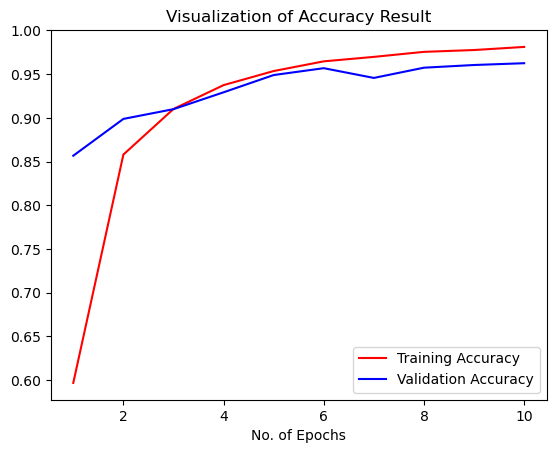

In [ ]:
epochs = [i for i in range(1, 11)]
plt.plot(epochs, history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()


## Some other metrics for model evaluation

In [26]:
class_name = validation_set.class_names

In [27]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [50]:

# Remove dependency on tensorflow-addons; use TF's RandomRotation for robustness checks & Grad-CAM visualization (cv2 still optional)
import tensorflow as tf
import numpy as np

# rotation layer (no external packages)
_rot_layer = tf.keras.layers.RandomRotation(0.15)

def rotated(x):
    return _rot_layer(x, training=True)

def add_noise(x, std=0.05):
    x = tf.clip_by_value(x + tf.random.normal(tf.shape(x), mean=0.0, stddev=std), 0.0, 1.0)
    return x

def brighter(x, delta=0.2):
    return tf.clip_by_value(x + delta, 0.0, 1.0)

# use these in your evaluation robustness checks, e.g.:
# _ = eval_perturbation(lambda x: add_noise(rescale(x)), "Noise")
# _ = eval_perturbation(lambda x: brighter(rescale(x)), "Brighten")
# _ = eval_perturbation(lambda x: rotated(rescale(x)), "Rotated")

import cv2
print("opencv-python (cv2):", cv2.__version__)


opencv-python (cv2): 4.13.0


In [28]:
import tensorflow as tf
import os
# Load pre-trained model if available
print('Current working directory:', os.getcwd())
model_path = 'trained_plant_disease_model.keras'
if os.path.exists(model_path):
    print(f'Loading pre-trained model from {model_path}...')
    try:
        cnn = tf.keras.models.load_model(model_path, safe_mode=False)
        print('Model loaded successfully (safe_mode=False)!')
    except Exception as e:
        print(f'Failed with safe_mode=False: {e}')
        try:
            cnn = tf.keras.models.load_model(model_path, compile=False)
            print('Model loaded successfully (compile=False)!')
        except Exception as e2:
            print(f'Failed to load: {e2}. Using untrained model.')
else:
    print(f'Pre-trained model not found. Using untrained model.')
try:
    test_set
except NameError:
    test_set = tf.keras.utils.image_dataset_from_directory("valid",
        labels="inferred", label_mode="categorical", class_names=None,
        color_mode="rgb", batch_size=1, image_size=(128,128), shuffle=False)
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

Current working directory: d:\plant disease dataset\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)
Loading pre-trained model from trained_plant_disease_model.keras...
Model loaded successfully (safe_mode=False)!
17572/17572 ━━━━━━━━━━━━━━━━━━━━ 237s 13ms/step


In [29]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [30]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [55]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [31]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [32]:
# Precision Recall Fscore
if 'class_name' not in locals():
    class_name = test_set.class_names
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.97      0.96       504
                                 Apple___Black_rot       0.97      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.91      0.99      0.95       440
                                   Apple___healthy       0.97      0.92      0.95       502
                               Blueberry___healthy       0.96      0.98      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.94      1.00      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.91      0.91       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.97      0.

### Confusion Matrix Visualization

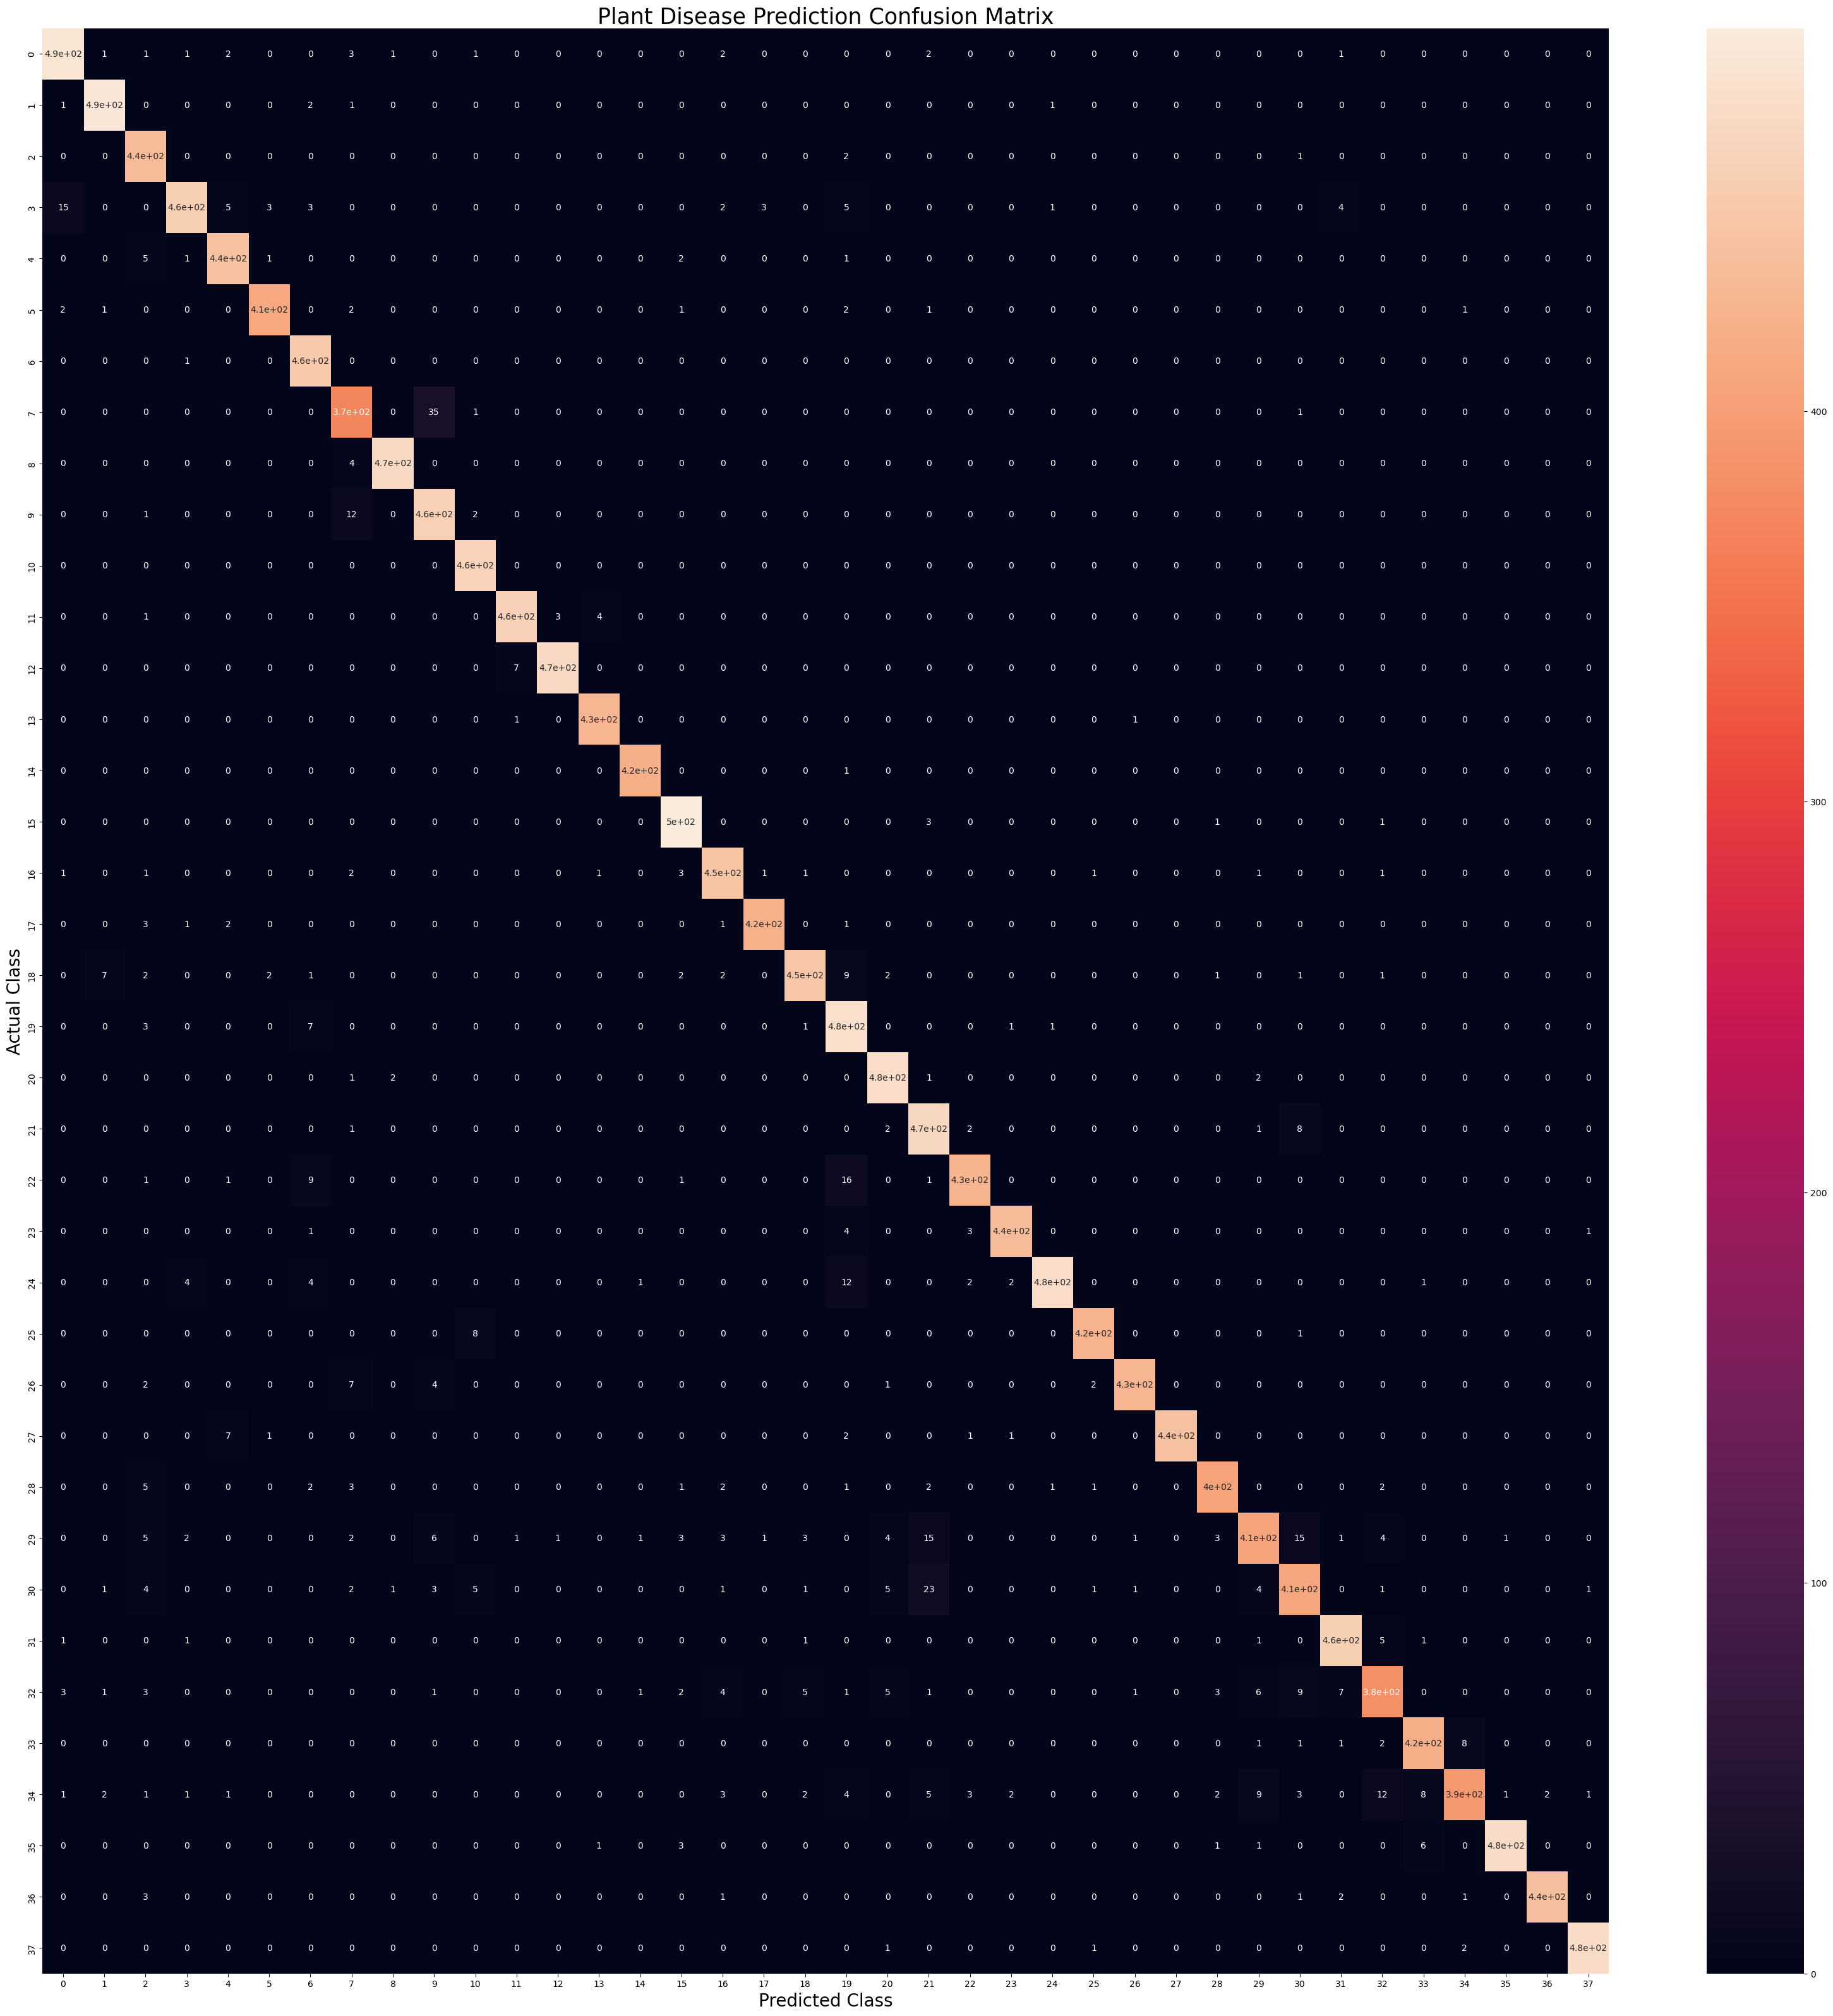

In [33]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

In [ ]:
# No extra installs needed — tf.keras.applications.ResNet50 is built into TensorFlow
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))
%pip install tqdm --quiet


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## ResNet50 Transfer Learning — Training & Comparison with CNN
Train ResNet50 (pretrained ImageNet weights, last conv block unfrozen) using `tf.keras.applications.ResNet50` on the same plant disease dataset for 10 epochs, then compare against the custom CNN.


In [1]:
import os, json
import tensorflow as tf

HIST_PATH  = 'resnet_history.json'
MODEL_PATH = 'resnet50_best.keras'
EPOCHS     = 10
BATCH_SIZE = 32
IMG_SIZE   = 224

# ── GPU check ────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU detected: {gpus[0].name}')
else:
    print('No GPU detected — running on CPU.')

# ── Load existing history or train ───────────────────────────
if os.path.exists(HIST_PATH):
    with open(HIST_PATH) as f:
        resnet_hist = json.load(f)
    print(f'Loaded existing ResNet50 history ({len(resnet_hist["accuracy"])} epochs)')
else:
    # ── Data pipelines (224x224 for ResNet50) ────────────────
    preprocess = tf.keras.applications.resnet50.preprocess_input

    resnet_train = tf.keras.utils.image_dataset_from_directory(
        'train', label_mode='categorical', batch_size=BATCH_SIZE,
        image_size=(IMG_SIZE, IMG_SIZE), shuffle=True
    ).map(lambda x, y: (preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    resnet_val = tf.keras.utils.image_dataset_from_directory(
        'valid', label_mode='categorical', batch_size=BATCH_SIZE,
        image_size=(IMG_SIZE, IMG_SIZE), shuffle=False
    ).map(lambda x, y: (preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    # ── Build model ──────────────────────────────────────────
    base = tf.keras.applications.ResNet50(
        weights='imagenet', include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    # Freeze all layers, then unfreeze the last conv block (layer4 ≈ conv5)
    base.trainable = False
    for layer in base.layers:
        if layer.name.startswith('conv5'):
            layer.trainable = True

    resnet_model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(38, activation='softmax')
    ])

    resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    resnet_model.summary()

    # ── Train ────────────────────────────────────────────────
    resnet_training = resnet_model.fit(
        resnet_train,
        validation_data=resnet_val,
        epochs=EPOCHS
    )

    resnet_hist = resnet_training.history

    # Save history & model
    with open(HIST_PATH, 'w') as f:
        json.dump(resnet_hist, f)
    resnet_model.save(MODEL_PATH)
    print(f'\nHistory saved  → {HIST_PATH}')
    print(f'Model saved    → {MODEL_PATH}')
    print(f'Best val acc   : {max(resnet_hist["val_accuracy"]):.4f}')


No GPU detected — running on CPU.
Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 47s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        77,862 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,665,574 (90.28 MB)

 Trainable params: 15,053,862 (57.43 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 5112s 2s/step - accuracy: 0.9490 - loss: 0.1818 - val_accuracy: 0.9875 - val_loss: 0.0453
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 6486s 3s/step - accuracy: 0.9893 - loss: 0.0341 - val_accuracy: 0.9874 - val_loss: 0.0459
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3274s 1s/step - accuracy: 0.9933 - loss: 0.0226 - val_accuracy: 0.9908 - val_loss: 0.0285
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3179s 1s/step - accuracy: 0.9943 - loss: 0.0182 - val_accuracy: 0.9950 - val_loss: 0.0165
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3091s 1s/step - accuracy: 0.9962 - loss: 0.0126 - val_accuracy: 0.9947 - val_loss: 0.0191
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3078s 1s/step - accuracy: 0.9965 - loss: 0.0111 - val_accuracy: 0.9941 - val_loss: 0.0207
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3075s 1s/step - accuracy: 0.9966 - loss: 0.0110 - val_accuracy: 0.9950 - val_loss: 0.0203
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3130s 1s/step - accuracy: 0.9976 -

Found 17572 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


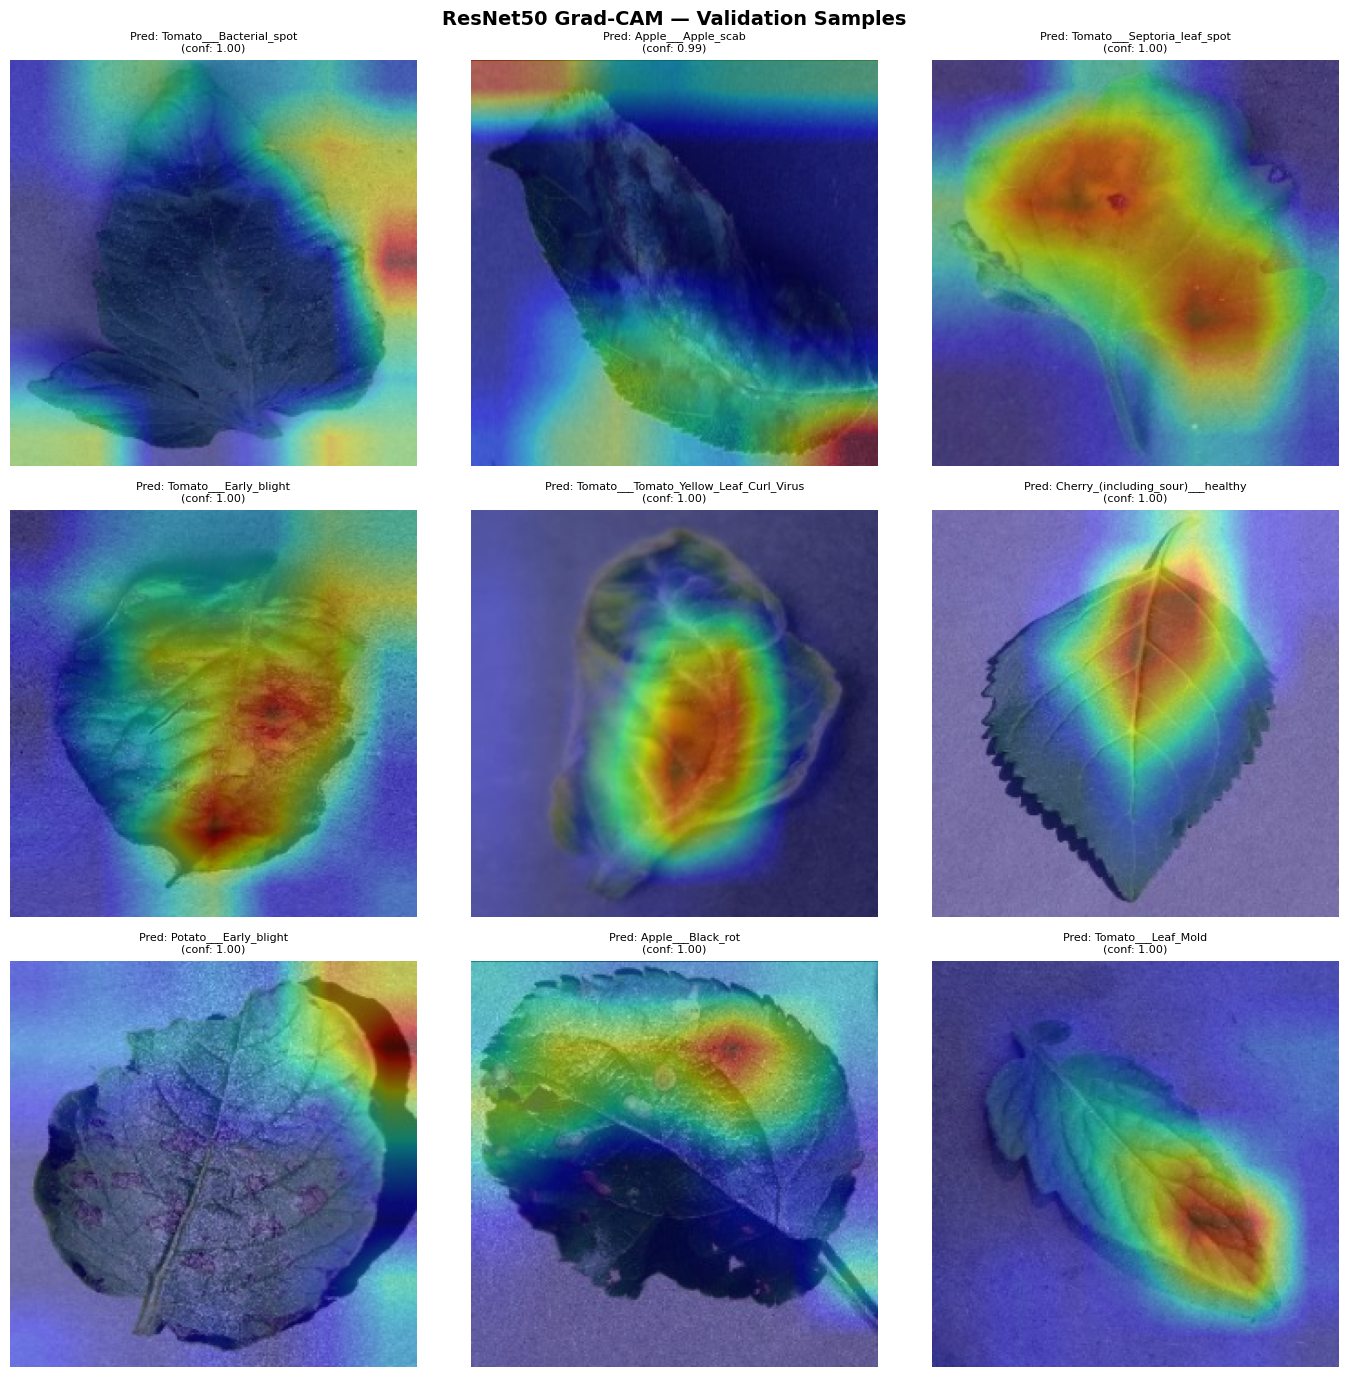

In [2]:

# Grad-CAM for TF/Keras ResNet50 using tf.GradientTape (Keras 3 compatible)
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

MODEL_PATH = 'resnet50_best.keras'
IMG_SIZE   = 224

if not os.path.exists(MODEL_PATH):
    print('ResNet50 model not found — run the training cell first.')
else:
    resnet_model = tf.keras.models.load_model(MODEL_PATH)

    class_names = tf.keras.utils.image_dataset_from_directory(
        'valid', label_mode='categorical', batch_size=1,
        image_size=(IMG_SIZE, IMG_SIZE), shuffle=False
    ).class_names

    preprocess = tf.keras.applications.resnet50.preprocess_input
    base_model  = resnet_model.layers[0]                          # ResNet50 base

    # Build two sub-models: input→conv5 output, and conv5→predictions
    # This avoids calling .output on an uncalled Sequential layer
    last_conv_layer = base_model.get_layer('conv5_block3_out')
    conv_model = tf.keras.Model(base_model.input, last_conv_layer.output)

    # Remaining layers of the Sequential after the base
    gap_layer     = resnet_model.layers[1]   # GlobalAveragePooling2D
    dropout_layer = resnet_model.layers[2]   # Dropout
    dense_layer   = resnet_model.layers[3]   # Dense(38, softmax)

    # Load a small sample of validation images
    sample_ds = tf.keras.utils.image_dataset_from_directory(
        'valid', label_mode='categorical', batch_size=9,
        image_size=(IMG_SIZE, IMG_SIZE), shuffle=True, seed=42
    )
    imgs_batch, _ = next(iter(sample_ds))
    imgs_pre = preprocess(imgs_batch)

    with tf.GradientTape() as tape:
        conv_out = conv_model(imgs_pre, training=False)   # (B, H, W, C)
        tape.watch(conv_out)
        x     = gap_layer(conv_out)
        x     = dropout_layer(x, training=False)
        preds = dense_layer(x)
        pred_idx  = tf.argmax(preds, axis=1)
        top_score = tf.reduce_max(preds, axis=1)

    grads    = tape.gradient(top_score, conv_out)           # (B, H, W, C)
    weights  = tf.reduce_mean(grads, axis=(1, 2))           # (B, C)
    cam_maps = tf.nn.relu(
        tf.einsum('bc,bhwc->bhw', weights, conv_out))       # (B, H, W)

    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    for i, ax in enumerate(axes.flat):
        img_np  = imgs_batch[i].numpy().astype('uint8')
        cam_np  = cam_maps[i].numpy()
        cam_np  = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)
        cam_res = tf.image.resize(cam_np[..., tf.newaxis],
                                  (IMG_SIZE, IMG_SIZE)).numpy()[..., 0]
        ax.imshow(img_np)
        ax.imshow(cam_res, cmap='jet', alpha=0.45)
        ax.set_title(f'Pred: {class_names[pred_idx[i]]}\n'
                     f'(conf: {preds[i, pred_idx[i]]:.2f})', fontsize=8)
        ax.axis('off')
    plt.suptitle('ResNet50 Grad-CAM — Validation Samples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Model Comparison: Custom CNN vs ResNet50


Metric                           Custom CNN   ResNet50
Final Train Accuracy                 0.9812     0.9981
Final Val Accuracy                   0.9626     0.9945
Final Train Loss                     0.0571     0.0059
Final Val Loss                       0.1227     0.0214
Best Val Accuracy                    0.9626     0.9954


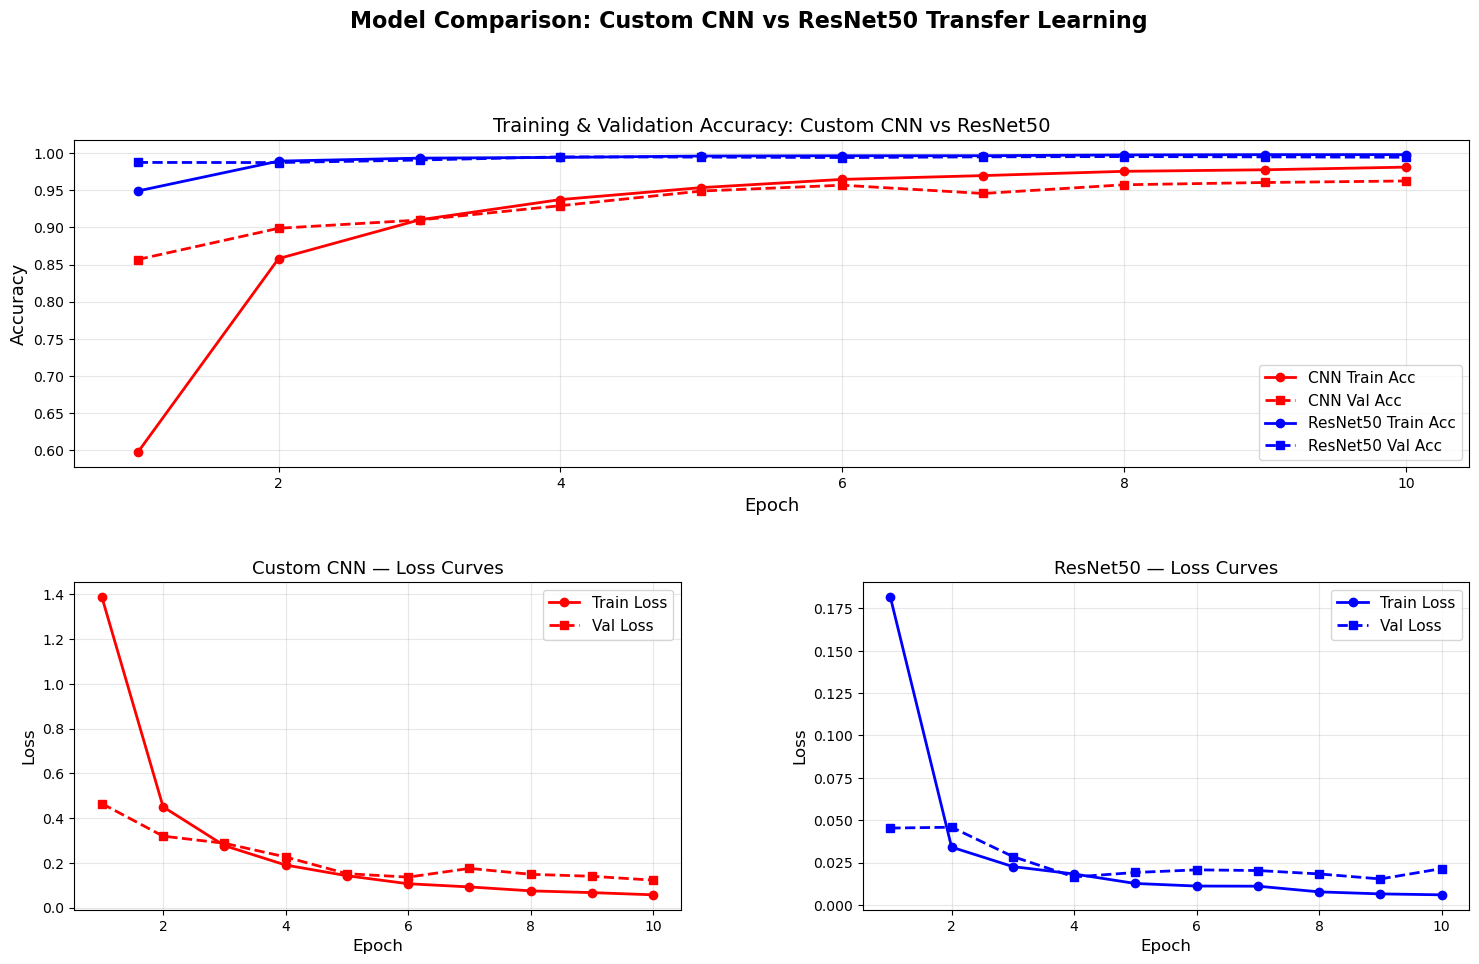

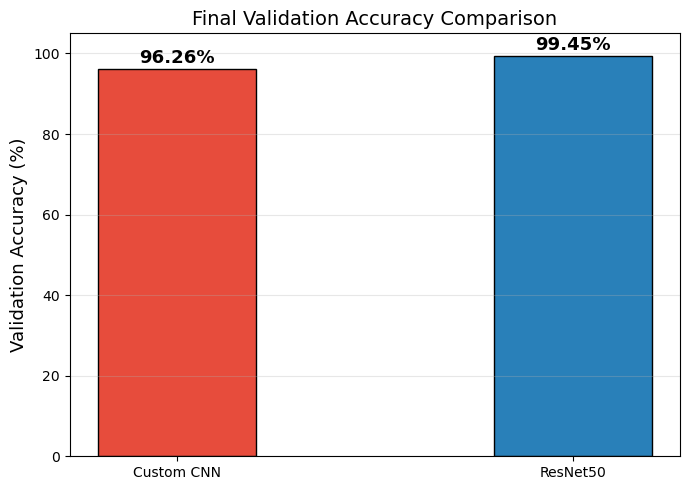

In [3]:
import json, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load CNN history ──────────────────────────────────────────
cnn_hist_path = 'training_hist.json'
if 'history' in dir() and isinstance(history, dict) and 'accuracy' in history:
    cnn_hist = history
else:
    with open(cnn_hist_path) as f:
        cnn_hist = json.load(f)

# ── Load ResNet50 history (Keras keys: accuracy, val_accuracy, loss, val_loss) ──
resnet_hist_path = 'resnet_history.json'
if 'resnet_hist' not in dir():
    with open(resnet_hist_path) as f:
        resnet_hist = json.load(f)

cnn_epochs    = list(range(1, len(cnn_hist['accuracy']) + 1))
resnet_epochs = list(range(1, len(resnet_hist['accuracy']) + 1))

# ── Summary table ─────────────────────────────────────────────
print('=' * 55)
print(f"{'Metric':<30} {'Custom CNN':>12} {'ResNet50':>10}")
print('=' * 55)
print(f"{'Final Train Accuracy':<30} {cnn_hist['accuracy'][-1]:>12.4f} {resnet_hist['accuracy'][-1]:>10.4f}")
print(f"{'Final Val Accuracy':<30} {cnn_hist['val_accuracy'][-1]:>12.4f} {resnet_hist['val_accuracy'][-1]:>10.4f}")
print(f"{'Final Train Loss':<30} {cnn_hist['loss'][-1]:>12.4f} {resnet_hist['loss'][-1]:>10.4f}")
print(f"{'Final Val Loss':<30} {cnn_hist['val_loss'][-1]:>12.4f} {resnet_hist['val_loss'][-1]:>10.4f}")
print(f"{'Best Val Accuracy':<30} {max(cnn_hist['val_accuracy']):>12.4f} {max(resnet_hist['val_accuracy']):>10.4f}")
print('=' * 55)

# ── Side-by-side plots ────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Accuracy comparison
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cnn_epochs,    cnn_hist['accuracy'],          'r-o',  linewidth=2, label='CNN Train Acc')
ax1.plot(cnn_epochs,    cnn_hist['val_accuracy'],      'r--s', linewidth=2, label='CNN Val Acc')
ax1.plot(resnet_epochs, resnet_hist['accuracy'],       'b-o',  linewidth=2, label='ResNet50 Train Acc')
ax1.plot(resnet_epochs, resnet_hist['val_accuracy'],   'b--s', linewidth=2, label='ResNet50 Val Acc')
ax1.set_xlabel('Epoch', fontsize=13)
ax1.set_ylabel('Accuracy', fontsize=13)
ax1.set_title('Training & Validation Accuracy: Custom CNN vs ResNet50', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# CNN loss
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(cnn_epochs, cnn_hist['loss'],     'r-o',  linewidth=2, label='Train Loss')
ax2.plot(cnn_epochs, cnn_hist['val_loss'], 'r--s', linewidth=2, label='Val Loss')
ax2.set_xlabel('Epoch', fontsize=12); ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Custom CNN — Loss Curves', fontsize=13)
ax2.legend(fontsize=11); ax2.grid(alpha=0.3)

# ResNet50 loss
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(resnet_epochs, resnet_hist['loss'],     'b-o',  linewidth=2, label='Train Loss')
ax3.plot(resnet_epochs, resnet_hist['val_loss'], 'b--s', linewidth=2, label='Val Loss')
ax3.set_xlabel('Epoch', fontsize=12); ax3.set_ylabel('Loss', fontsize=12)
ax3.set_title('ResNet50 — Loss Curves', fontsize=13)
ax3.legend(fontsize=11); ax3.grid(alpha=0.3)

plt.suptitle('Model Comparison: Custom CNN vs ResNet50 Transfer Learning', fontsize=16, fontweight='bold', y=1.01)
plt.show()

# ── Bar chart: final val accuracy ─────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 5))
models   = ['Custom CNN', 'ResNet50']
val_accs = [cnn_hist['val_accuracy'][-1], resnet_hist['val_accuracy'][-1]]
colors   = ['#e74c3c', '#2980b9']
bars = ax.bar(models, [v * 100 for v in val_accs], color=colors, width=0.4, edgecolor='black')
for bar, v in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{v*100:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Validation Accuracy (%)', fontsize=13)
ax.set_title('Final Validation Accuracy Comparison', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
